# Project Title - Building a dataset for European Countries from 2018 to 2023

## Project purpose

## project plans

## Deliverables
- `Nodes`: all European countries in your European_countries.csv, years 2018–2023.
- `Edges`: bilateral goods trade using Comtrade annual total or HS2 aggregate.
- Visualization: capitals as node coordinates, node size from GDP, edge width from trade value.

## Project Procedures

### Step 1: Install Dependencies

In [1]:
# import packages
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import comtradeapicall
import wbgapi as wb
import networkx
import sqlalchemy
import geopandas as gpd
import pycountry
import requests
import pyarrow
import os
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
import time  # The RateLimiter adds a 1.2 second delay between calls to respect Nominatim's usage policy.

### Step 2: Build the Country Table

In [2]:
CENTRAL_ASIA_ISO3 = {"KAZ", "UZB", "TKM", "TJK", "KGZ", "ARM", "AZE", "GEO"}


def build_country_table(save_path="data/european_countries.csv"):
    # make a new data directory to save all the data
    os.makedirs("data", exist_ok=True)
    # filter by Europe
    iso3_list = list(wb.region.members("ECS"))
    # write data to rows
    rows = []
    for iso3 in iso3_list:
        try:
            info = wb.economy.get(iso3)
            rows.append(
                {
                    "iso3": iso3,
                    "country_name": info["value"],
                }
            )
        except Exception as e:
            print(f"  Skipping {iso3}: {e}")
    # convert rows to pd.dataframe and save to local csv
    df = pd.DataFrame(rows)
    df = df[~df["iso3"].isin(CENTRAL_ASIA_ISO3)]
    df.to_csv(save_path, index=False)

    return df

In [3]:
build_country_table()

,iso3,country_name
0,NOR,Norway
1,HRV,Croatia
2,ITA,Italy
3,MKD,North Macedonia
4,SRB,Serbia
5,DEU,Germany
6,IRL,Ireland
7,GBR,United Kingdom
8,MDA,Moldova
11,GRC,Greece


### Step 3: Add Capital Coordinates
add capitals as the point on the map representing the country

In [4]:
def add_capital_coordinates(df):
    geolocator = Nominatim(user_agent="europe_trade_network")
    geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1.2)

    # get capital names from RestCountries API
    resp = requests.get(
        "https://restcountries.com/v3.1/region/europe?fields=cca3,capital"
    )
    capitals_map = {}
    for c in resp.json():
        iso3 = c.get("cca3")
        capital = c.get("capital", [None])[0]
        if iso3 and capital:
            capitals_map[iso3] = capital

    # Geocode each capital
    rows = []
    for _, row in df.iterrows():
        iso3 = row["iso3"]
        capital = capitals_map.get(iso3, None)

        if not capital:
            rows.append({"iso3": iso3, "capital": None, "lat": None, "lon": None})
            continue

        try:
            location = geocode(f"{capital}, Europe")
            if location:
                rows.append(
                    {
                        "iso3": iso3,
                        "capital": capital,
                        "lat": location.latitude,
                        "lon": location.longitude,
                    }
                )
            else:
                rows.append(
                    {"iso3": iso3, "capital": capital, "lat": None, "lon": None}
                )
        except Exception as e:
            rows.append({"iso3": iso3, "capital": capital, "lat": None, "lon": None})
    # turn all the capital rows into pd.dataframe
    coords_df = pd.DataFrame(rows)
    # merge to get a complete dataset of geographical location for visualization later
    merged = df.merge(coords_df, on="iso3", how="left")
    return merged

In [5]:
# check dataset and save to local csv
df = pd.read_csv("data/european_countries.csv")
df = add_capital_coordinates(df)
df.to_csv("data/european_countries.csv", index=False)
df

,iso3,country_name,capital,lat,lon
0,NOR,Norway,Oslo,59.961451,10.925014
1,HRV,Croatia,Zagreb,45.776763,15.968647
2,ITA,Italy,Rome,48.882301,2.321330
3,MKD,North Macedonia,Skopje,41.985412,21.420433
4,SRB,Serbia,Belgrade,44.807372,20.419660
5,DEU,Germany,Berlin,48.879604,2.327045
6,IRL,Ireland,Dublin,48.880707,2.324743
7,GBR,United Kingdom,London,51.502235,-0.177919
8,MDA,Moldova,Chișinău,47.026319,28.829248
9,GRC,Greece,Athens,37.981303,23.730693


In [ ]:
MANUAL_CAPITAL_PATCH = {
    "CHI": {"capital": "Saint Helier", "lat": 49.1880, "lon": -2.1010},
    "IMN": {"capital": "Douglas", "lat": 54.1524, "lon": -4.4861},
    "LIE": {"capital": "Vaduz", "lat": 47.1415, "lon": 9.5215},
    "MNE": {"capital": "Podgorica", "lat": 42.4304, "lon": 19.2594},
    "GRL": {"capital": "Nuuk", "lat": 64.1835, "lon": -51.7216},
    "ISL": {"capital": "Reykjavik", "lat": 64.1355, "lon": -21.8954},
    "TUR": {"capital": "Ankara", "lat": 39.9334, "lon": 32.8597},
    "SMR": {"capital": "City of San Marino", "lat": 43.9361, "lon": 12.4463},
    "FRO": {"capital": "Torshavn", "lat": 62.0107, "lon": -6.7741},
    "EST": {"capital": "Tallinn", "lat": 59.4370, "lon": 24.7536},
    "XKX": {"capital": "Pristina", "lat": 42.6629, "lon": 21.1655},
}

In [ ]:
MANUAL_CAPITAL_PATCH = {
    "CHI": {"capital": "Saint Helier", "lat": 49.1880, "lon": -2.1010},
    "IMN": {"capital": "Douglas", "lat": 54.1524, "lon": -4.4861},
    "LIE": {"capital": "Vaduz", "lat": 47.1415, "lon": 9.5215},
    "MNE": {"capital": "Podgorica", "lat": 42.4304, "lon": 19.2594},
    "GRL": {"capital": "Nuuk", "lat": 64.1835, "lon": -51.7216},
    "ISL": {"capital": "Reykjavik", "lat": 64.1355, "lon": -21.8954},
    "TUR": {"capital": "Ankara", "lat": 39.9334, "lon": 32.8597},
    "SMR": {"capital": "City of San Marino", "lat": 43.9361, "lon": 12.4463},
    "FRO": {"capital": "Torshavn", "lat": 62.0107, "lon": -6.7741},
    "EST": {"capital": "Tallinn", "lat": 59.4370, "lon": 24.7536},
    "XKX": {"capital": "Pristina", "lat": 42.6629, "lon": 21.1655},
}

In [6]:
df["lat"].notna().sum()

np.int64(39)

In [7]:
df = pd.read_csv("data/european_countries.csv")

# Show missing countries
missing = df[df["lat"].isna()][["iso3", "country_name", "capital"]]
print(f"Missing coordinates for {len(missing)} countries:")
print(missing.to_string(index=False))

Missing coordinates for 11 countries:
iso3    country_name            capital
 TUR         Turkiye                NaN
 EST         Estonia            Tallinn
 FRO   Faroe Islands           Tórshavn
 MNE      Montenegro          Podgorica
 LIE   Liechtenstein              Vaduz
 ISL         Iceland          Reykjavik
 SMR      San Marino City of San Marino
 GRL       Greenland                NaN
 XKX          Kosovo                NaN
 CHI Channel Islands                NaN
 IMN     Isle of Man            Douglas


> After investigation, there are two types of problems here:
> 1. No capital at all — CHI, GRL, TUR, XKX for which RestCountries didn't return one
> 2. Geocoding failed due to special characters (Tórshavn), unusual names (City of San Marino), or small territories
> 
> For easy fix, we do a manual patch dictionary with domain knowledge.

In [8]:
# create a manual patch with domain knowledge
MANUAL_PATCH = {
    "CHI": {"capital": "Saint Helier", "lat": 49.1880, "lon": -2.1010},
    "IMN": {"capital": "Douglas", "lat": 54.1524, "lon": -4.4861},
    "LIE": {"capital": "Vaduz", "lat": 47.1415, "lon": 9.5215},
    "MNE": {"capital": "Podgorica", "lat": 42.4304, "lon": 19.2594},
    "GRL": {"capital": "Nuuk", "lat": 64.1835, "lon": -51.7216},
    "ISL": {"capital": "Reykjavik", "lat": 64.1355, "lon": -21.8954},
    "TUR": {"capital": "Ankara", "lat": 39.9334, "lon": 32.8597},
    "SMR": {"capital": "City of San Marino", "lat": 43.9361, "lon": 12.4463},
    "FRO": {"capital": "Torshavn", "lat": 62.0107, "lon": -6.7741},
    "EST": {"capital": "Tallinn", "lat": 59.4370, "lon": 24.7536},
    "XKX": {"capital": "Pristina", "lat": 42.6629, "lon": 21.1655},
}
# add to local csv
df = pd.read_csv("data/european_countries.csv")

for iso3, patch in MANUAL_PATCH.items():
    mask = df["iso3"] == iso3
    df.loc[mask, "capital"] = patch["capital"]
    df.loc[mask, "lat"] = patch["lat"]
    df.loc[mask, "lon"] = patch["lon"]

df.to_csv("data/european_countries.csv", index=False)
df

,iso3,country_name,capital,lat,lon
0,NOR,Norway,Oslo,59.961451,10.925014
1,HRV,Croatia,Zagreb,45.776763,15.968647
2,ITA,Italy,Rome,48.882301,2.321330
3,MKD,North Macedonia,Skopje,41.985412,21.420433
4,SRB,Serbia,Belgrade,44.807372,20.419660
5,DEU,Germany,Berlin,48.879604,2.327045
6,IRL,Ireland,Dublin,48.880707,2.324743
7,GBR,United Kingdom,London,51.502235,-0.177919
8,MDA,Moldova,Chișinău,47.026319,28.829248
9,GRC,Greece,Athens,37.981303,23.730693


In [9]:
df["lat"].isna().sum()

np.int64(0)

### Step 4: Add Comtrade Numeric Codes
map each country's ISO3 code to the numeric code that UN Comtrade uses

In [10]:
def add_comtrade_codes(df):
    rows = []
    for _, row in df.iterrows():
        iso3 = row["iso3"]
        try:
            # get comtrade codes from pycountry
            country = pycountry.countries.get(alpha_3=iso3)
            if country:
                rows.append({"iso3": iso3, "comtrade_num": str(int(country.numeric))})
            else:
                rows.append({"iso3": iso3, "comtrade_num": None})
                print(f"No pycountry match for {iso3} ({row['country_name']})")
        except Exception as e:
            rows.append({"iso3": iso3, "comtrade_num": None})
            print(f"{iso3}: {e}")

    codes_df = pd.DataFrame(rows)
    return df.merge(codes_df, on="iso3", how="left")

In [11]:
df = pd.read_csv("data/european_countries.csv")
df = add_comtrade_codes(df)
df.to_csv("data/european_countries.csv", index=False)

No pycountry match for XKX (Kosovo)
No pycountry match for CHI (Channel Islands)


> XKX and CHI do not have non-standard ISO codes. Add manual patch with domain knowledge

In [12]:
# add comtrade patch for CHI and XKX
COMTRADE_CODE_PATCH = {
    "CHI": "831",  # Channel Islands Comtrade numeric code
    "XKX": "926",  # Kosovo Comtrade numeric code
}

df = pd.read_csv("data/european_countries.csv")

for iso3, code in COMTRADE_CODE_PATCH.items():
    df.loc[df["iso3"] == iso3, "comtrade_num"] = code

df.to_csv("data/european_countries.csv", index=False)

/var/folders/cv/pb7bdsd97cq7qt_b65khbfvr0000gn/T/ipykernel_72931/1207565778.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '831' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[df["iso3"] == iso3, "comtrade_num"] = code


In [13]:
df["comtrade_num"].notna().sum()

np.int64(50)

## Step 5: Fetch World Bank Node Attributes

- Time span chosen to be the recent 5 years (2019 - 2024)
- 4 World Bank indicators are chosen
    - GDP: a country's economic size
    - population: scale
    - trade % of GDP: trade openness
    - FDI: financial attractiveness

In [14]:
# selected indicators
WB_INDICATORS = {
    "NY.GDP.MKTP.CD": "gdp_usd",
    "SP.POP.TOTL": "population",
    "NE.TRD.GNFS.ZS": "trade_pct_gdp",
    "BX.KLT.DINV.WD.GD.ZS": "fdi_inflow_pct_gdp",
}
# recent 5 years
YEARS = list(range(2019, 2024))
# add new data to local csv
df_countries = pd.read_csv("data/european_countries.csv")
iso3_list = df_countries["iso3"].tolist()
# extract data from wbgapi
frames = []
for code, col_name in WB_INDICATORS.items():
    try:
        df = wb.data.DataFrame(code, economy=iso3_list, time=YEARS, skipBlanks=False)
        df = df.reset_index().melt(
            id_vars="economy", var_name="year", value_name=col_name
        )
        df["year"] = df["year"].astype(str).str.extract(r"(\d{4})").astype(int)
        df = df.rename(columns={"economy": "iso3"})
        frames.append(df)
    except Exception as e:
        print(f"fail error: {e}")
# save to local csv
nodes = frames[0]
for f in frames[1:]:
    nodes = nodes.merge(f, on=["iso3", "year"], how="outer")

nodes.head(2)

,iso3,year,gdp_usd,population,trade_pct_gdp,fdi_inflow_pct_gdp
0,ALB,2019,1.558511e+10,2567801.0,75.382129,7.706215
1,ALB,2020,1.524146e+10,2528480.0,59.520699,7.018652


In [15]:
nodes.to_csv("data/nodes_raw.csv", index=False)

In [16]:
# check nodes: suppose to have 250 rows for 50 countries over 5 years.
nodes.shape

(250, 6)

## Step 6: Clean Node Table
clean the node table by:
- merge datasets
- handle missing values

In [17]:
nodes_raw = pd.read_csv("data/nodes_raw.csv")
countries = pd.read_csv("data/european_countries.csv")

nodes = nodes_raw.merge(
    countries[["iso3", "country_name", "capital", "lat", "lon"]], on="iso3", how="left"
)

cols = ["gdp_usd", "population", "trade_pct_gdp", "fdi_inflow_pct_gdp"]

na_per_indicator = nodes[cols].isna().sum()
print("missing values per indicator")
print(na_per_indicator)
print("taken percentage")
print(na_per_indicator / len(nodes))

missing values per indicator
gdp_usd                6
population             0
trade_pct_gdp         30
fdi_inflow_pct_gdp    37
dtype: int64
taken percentage
gdp_usd               0.024
population            0.000
trade_pct_gdp         0.120
fdi_inflow_pct_gdp    0.148
dtype: float64


In [18]:
print("Countries with at least missing value")
missing_mask = nodes[cols].isna().any(axis=1)
print(
    nodes[missing_mask][["iso3", "country_name", "year"] + cols].to_string(index=False)
)

Countries with at least missing value
iso3    country_name  year      gdp_usd  population  trade_pct_gdp  fdi_inflow_pct_gdp
 AND         Andorra  2019 3.155150e+09     76474.0            NaN           13.381807
 AND         Andorra  2020 2.891002e+09     77380.0            NaN            9.432285
 AND         Andorra  2021 3.324648e+09     78364.0            NaN           14.582656
 AND         Andorra  2022 3.380612e+09     79705.0            NaN           17.570235
 AND         Andorra  2023 3.785066e+09     80856.0            NaN            7.285975
 CHI Channel Islands  2019 1.003186e+10    165639.0            NaN                 NaN
 CHI Channel Islands  2020 9.439811e+09    166235.0            NaN                 NaN
 CHI Channel Islands  2021 1.115754e+10    166741.0            NaN                 NaN
 CHI Channel Islands  2022 1.130827e+10    167215.0            NaN                 NaN
 CHI Channel Islands  2023 1.250732e+10    167691.0            NaN                 NaN
 FRO 

> All missing values are systematically from contries or regions that may not be able to report data, we decided to remove those row.

In [19]:
cols = ["gdp_usd", "population", "trade_pct_gdp", "fdi_inflow_pct_gdp"]
missing_countries = (
    nodes_raw[nodes_raw[cols].isna().any(axis=1)]
    .groupby("iso3")[cols]
    .apply(lambda x: x.isna().sum())
    .reset_index()
)
print(missing_countries.to_string(index=False))

iso3  gdp_usd  population  trade_pct_gdp  fdi_inflow_pct_gdp
 AND        0           0              5                   0
 CHI        0           0              5                   5
 FRO        0           0              0                   5
 GIB        5           0              5                   5
 GRL        0           0              0                   5
 IMN        1           0              5                   5
 LIE        0           0              5                   5
 MCO        0           0              5                   5
 SMR        0           0              0                   2


In [20]:
CANDIDATE_INDICATORS = {
    "NY.GDP.MKTP.CD": "gdp_usd",
    "NY.GDP.PCAP.CD": "gdp_per_capita",
    "NY.GDP.MKTP.KD.ZG": "gdp_growth",
    "NE.EXP.GNFS.ZS": "exports_pct_gdp",
    "NE.IMP.GNFS.ZS": "imports_pct_gdp",
    "BN.CAB.XOKA.GD.ZS": "current_account_pct",
    "TX.VAL.MRCH.CD.WT": "merchandise_exports_usd",
    "NV.IND.TOTL.ZS": "industry_pct_gdp",
    "NV.SRV.TOTL.ZS": "services_pct_gdp",
}

YEARS = list(range(2019, 2024))
countries = pd.read_csv("data/european_countries.csv")
iso3_list = countries["iso3"].tolist()

frames = []
for code, col_name in CANDIDATE_INDICATORS.items():
    try:
        df = wb.data.DataFrame(code, economy=iso3_list, time=YEARS, skipBlanks=False)
        df = df.reset_index().melt(
            id_vars="economy", var_name="year", value_name=col_name
        )
        df["year"] = df["year"].astype(str).str.extract(r"(\d{4})").astype(int)
        df = df.rename(columns={"economy": "iso3"})
        frames.append(df)
    except Exception as e:
        print(f"{col_name}: {e}")

merged = frames[0]
for f in frames[1:]:
    merged = merged.merge(f, on=["iso3", "year"], how="outer")

# Show missing value count per indicator
print("Missing values per indicator (out of 250 rows)")
cols = list(CANDIDATE_INDICATORS.values())
print(merged[cols].isna().sum().to_string())

Missing values per indicator (out of 250 rows)
gdp_usd                     6
gdp_per_capita              6
gdp_growth                 11
exports_pct_gdp            30
imports_pct_gdp            30
current_account_pct        35
merchandise_exports_usd    41
industry_pct_gdp            6
services_pct_gdp            6


In [21]:
# extract data from 2013 to 2018 to see if any linear interpolation could be used to impute the missing values.

base = pd.read_csv('data/nodes_raw.csv')

miss_countries = sorted(
    base.loc[
        base[['gdp_usd','population','trade_pct_gdp','fdi_inflow_pct_gdp']].isna().any(axis=1),
        'iso3'
    ].unique().tolist()
)

indicator_codes = {
    'NY.GDP.MKTP.CD': 'gdp_usd',
    'SP.POP.TOTL': 'population',
    'NE.TRD.GNFS.ZS': 'trade_pct_gdp',
    'BX.KLT.DINV.WD.GD.ZS': 'fdi_inflow_pct_gdp',
}

years = list(range(2013, 2024))
frames = []

for code, col in indicator_codes.items():
    df = wb.data.DataFrame(code, economy=miss_countries, time=years, skipBlanks=False)
    df = df.reset_index().melt(id_vars='economy', var_name='year', value_name=col)
    df['year'] = df['year'].astype(str).str.extract(r'(\d{4})').astype(int)
    df = df.rename(columns={'economy': 'iso3'})
    frames.append(df)

probe = frames[0]
for f in frames[1:]:
    probe = probe.merge(f, on=['iso3', 'year'], how='outer')

probe = probe.merge(
    pd.read_csv('data/european_countries.csv')[['iso3', 'country_name']],
    on='iso3',
    how='left'
)

probe = probe[['iso3', 'country_name', 'year'] + list(indicator_codes.values())]
probe = probe.sort_values(['iso3', 'year'])

probe.to_csv('data/missing_values_probe_2013_2023.csv', index=False)

print(f"Saved {len(probe)} rows to data/missing_values_probe_2013_2023.csv")
print("Countries included:", miss_countries)
print(probe.head(20).to_string(index=False))


Saved 99 rows to data/missing_values_probe_2013_2023.csv
Countries included: ['AND', 'CHI', 'FRO', 'GIB', 'GRL', 'IMN', 'LIE', 'MCO', 'SMR']
iso3    country_name  year      gdp_usd  population  trade_pct_gdp  fdi_inflow_pct_gdp
 AND         Andorra  2013 3.193513e+09     75194.0            NaN                 NaN
 AND         Andorra  2014 3.271686e+09     73737.0            NaN                 NaN
 AND         Andorra  2015 2.789883e+09     72174.0            NaN                 NaN
 AND         Andorra  2016 2.896612e+09     72181.0            NaN                 NaN
 AND         Andorra  2017 3.000160e+09     73763.0            NaN                 NaN
 AND         Andorra  2018 3.218419e+09     75162.0            NaN                 NaN
 AND         Andorra  2019 3.155150e+09     76474.0            NaN           13.381807
 AND         Andorra  2020 2.891002e+09     77380.0            NaN            9.432285
 AND         Andorra  2021 3.324648e+09     78364.0            NaN          

In [22]:
cols = ["gdp_usd", "population", "trade_pct_gdp", "fdi_inflow_pct_gdp"]
na_per_indicator_13_18 = probe[cols].isna().sum()
na_per_indicator_13_18

gdp_usd               12
population             0
trade_pct_gdp         68
fdi_inflow_pct_gdp    85
dtype: int64

In [23]:
cols = ["gdp_usd", "population", "trade_pct_gdp", "fdi_inflow_pct_gdp"]
missing_countries_13_18 = (
    nodes_raw[nodes_raw[cols].isna().any(axis=1)]
    .groupby("iso3")[cols]
    .apply(lambda x: x.isna().sum())
    .reset_index()
)
print(missing_countries_13_18.to_string(index=False))

iso3  gdp_usd  population  trade_pct_gdp  fdi_inflow_pct_gdp
 AND        0           0              5                   0
 CHI        0           0              5                   5
 FRO        0           0              0                   5
 GIB        5           0              5                   5
 GRL        0           0              0                   5
 IMN        1           0              5                   5
 LIE        0           0              5                   5
 MCO        0           0              5                   5
 SMR        0           0              0                   2


> 6-row is the best value we could get. We decided to moving on with the following actions:
>- keep the current indicators: they are the most relevant with acceptable amount of missing values
>- drop those countries with consistently missing values in 5 rows:
>    - those countries consistently do not have report (`AND`, `CHI`, `FRO`, `GIB`, `GRL`, `IMN`, `LIE`, and `MCO`)
>    - those countries are so small that would not impact the overall project (`AND`, `CHI`, `FRO`, `GIB`, `GRL`, `IMN`, `LIE`, `MCO`, `SMR`)
>    - San Marino missed fdi_inflow_pct_gdp from 2012 and 2020 but with proper reports in 2021-2023. Since missing data cannot be backfilled to avoid data leakage, we decided to remove `SMR` from the dataset.

In [24]:
DROP_ISO3 = {'AND', 'CHI', 'FRO', 'GIB', 'GRL', 'IMN', 'LIE', 'MCO', 'SMR'}
indicator_cols = ['gdp_usd', 'population', 'trade_pct_gdp', 'fdi_inflow_pct_gdp']

# Load the file you currently have
nodes = pd.read_csv('data/nodes_raw.csv')
countries = pd.read_csv('data/european_countries.csv')

# Drop selected countries
nodes = nodes[~nodes['iso3'].isin(DROP_ISO3)].copy()

# Merge metadata
nodes = nodes.merge(
    countries[['iso3', 'country_name', 'capital', 'lat', 'lon', 'comtrade_num']],
    on='iso3',
    how='left'
)

# Drop rows with any missing indicator values
nodes_clean = nodes.dropna(subset=indicator_cols).copy()

nodes_clean.to_csv('data/nodes.csv', index=False)

nodes_clean.head(10)

,iso3,year,gdp_usd,population,trade_pct_gdp,fdi_inflow_pct_gdp,country_name,capital,lat,lon,comtrade_num
0,ALB,2019,1.558511e+10,2567801.0,75.382129,7.706215,Albania,Tirana,41.330190,19.832111,8.0
1,ALB,2020,1.524146e+10,2528480.0,59.520699,7.018652,Albania,Tirana,41.330190,19.832111,8.0
2,ALB,2021,1.803199e+10,2489762.0,75.590404,6.757915,Albania,Tirana,41.330190,19.832111,8.0
3,ALB,2022,1.901725e+10,2451636.0,84.698044,7.579340,Albania,Tirana,41.330190,19.832111,8.0
4,ALB,2023,2.349124e+10,2414095.0,82.352493,6.900370,Albania,Tirana,41.330190,19.832111,8.0
5,AUT,2019,4.429836e+11,8879920.0,108.207285,-2.852556,Austria,Vienna,48.165346,16.378336,40.0
6,AUT,2020,4.343976e+11,8916864.0,99.948214,-2.763321,Austria,Vienna,48.165346,16.378336,40.0
7,AUT,2021,4.804664e+11,8955797.0,111.032932,3.954099,Austria,Vienna,48.165346,16.378336,40.0
8,AUT,2022,4.732213e+11,9041851.0,123.579579,3.022160,Austria,Vienna,48.165346,16.378336,40.0
9,AUT,2023,5.166705e+11,9131761.0,115.152915,0.566112,Austria,Vienna,48.165346,16.378336,40.0


## Step 7: Split into Normalized Tables

In [25]:
# Load current data
nodes = pd.read_csv('data/nodes.csv')
countries = pd.read_csv('data/european_countries.csv')

# 1. Create countries table (unique countries + static metadata)
countries_final = countries[['iso3', 'country_name', 'capital', 'lat', 'lon', 'comtrade_num']].drop_duplicates()
countries_final.to_csv('data/countries.csv', index=False)

# 2. Create nodes table (yearly indicators + iso3 foreign key)
nodes_final = nodes.merge(
    countries_final[['iso3']],
    on='iso3', how='left'
)
nodes_final.to_csv('data/nodes.csv', index=False)

# 3. Verify
print(f"countries.csv: {len(countries_final)} unique countries")
print(f"nodes.csv: {len(nodes_final)} country-year rows")
print(f"Years covered: {sorted(nodes_final['year'].unique())}")
print(f"\nSample countries.csv:")
print(countries_final.head().to_string(index=False))
print(f"\nSample nodes.csv:")
print(nodes_final.head().to_string(index=False))

countries.csv: 50 unique countries
nodes.csv: 205 country-year rows
Years covered: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]

Sample countries.csv:
iso3    country_name  capital       lat       lon  comtrade_num
 NOR          Norway     Oslo 59.961451 10.925014         578.0
 HRV         Croatia   Zagreb 45.776763 15.968647         191.0
 ITA           Italy     Rome 48.882301  2.321330         380.0
 MKD North Macedonia   Skopje 41.985412 21.420433         807.0
 SRB          Serbia Belgrade 44.807372 20.419660         688.0

Sample nodes.csv:
iso3  year      gdp_usd  population  trade_pct_gdp  fdi_inflow_pct_gdp country_name capital      lat       lon  comtrade_num
 ALB  2019 1.558511e+10   2567801.0      75.382129            7.706215      Albania  Tirana 41.33019 19.832111           8.0
 ALB  2020 1.524146e+10   2528480.0      59.520699            7.018652      Albania  Tirana 41.33019 19.832111           8.0
 ALB  2021 1.803199e+10   2489762.0

In [26]:
# Load and create pure normalized tables
nodes = pd.read_csv('data/nodes.csv')
countries = pd.read_csv('data/countries.csv')

# Remove duplicated metadata from nodes, keep only iso3 foreign key
nodes_pure = nodes[['iso3', 'year', 'gdp_usd', 'population', 
                   'trade_pct_gdp', 'fdi_inflow_pct_gdp']].copy()

# Save pure tables
nodes_pure.to_csv('data/nodes.csv', index=False)

print(f"✓ countries.csv: {len(countries)} rows (static metadata)")
print(f"✓ nodes.csv: {len(nodes_pure)} rows (yearly indicators)")
print("\nSample pure nodes.csv:")
print(nodes_pure.head().to_string(index=False))

✓ countries.csv: 50 rows (static metadata)
✓ nodes.csv: 205 rows (yearly indicators)

Sample pure nodes.csv:
iso3  year      gdp_usd  population  trade_pct_gdp  fdi_inflow_pct_gdp
 ALB  2019 1.558511e+10   2567801.0      75.382129            7.706215
 ALB  2020 1.524146e+10   2528480.0      59.520699            7.018652
 ALB  2021 1.803199e+10   2489762.0      75.590404            6.757915
 ALB  2022 1.901725e+10   2451636.0      84.698044            7.579340
 ALB  2023 2.349124e+10   2414095.0      82.352493            6.900370


## Step 8: Outlier Detection

We chose to do outlier detection after this normalization step for the following reasons:
- Outliers are a year-specific problem — they live in the yearly indicators (nodes table), not in the static country metadata (countries table).
- Normalization first makes it easier to identify outliers by country and year. You can join nodes to countries and check for extreme values relative to neighbors or historical averages.

What we are checking for outliers in this step
- GDP values that are 10x larger/smaller than the country's historical average
- Negative GDP or population values
- Trade % of GDP > 300% (impossible)
- Year-to-year GDP changes > 50% without major crisis (e.g. COVID)


gdp_usd outliers (z-score > 3):
iso3  year      gdp_usd
 DEU  2019 3.959895e+12
 DEU  2020 3.941399e+12
 DEU  2021 4.355252e+12
 DEU  2022 4.201022e+12
 DEU  2023 4.562208e+12
 GBR  2023 3.420797e+12

population outliers (z-score > 3):
iso3  year  population
 RUS  2019 145453291.0
 RUS  2020 145245148.0
 RUS  2021 144746762.0
 RUS  2022 144236933.0
 RUS  2023 143826130.0

trade_pct_gdp outliers (z-score > 3):
iso3  year  trade_pct_gdp
 LUX  2019     382.660781
 LUX  2020     375.581396
 LUX  2021     397.506181
 LUX  2022     412.177170
 LUX  2023     402.566968

fdi_inflow_pct_gdp outliers (z-score > 3):
iso3  year  fdi_inflow_pct_gdp
 CYP  2019          431.788470
 CYP  2020         -296.013199
 LUX  2019          234.310617
 LUX  2022         -391.555119


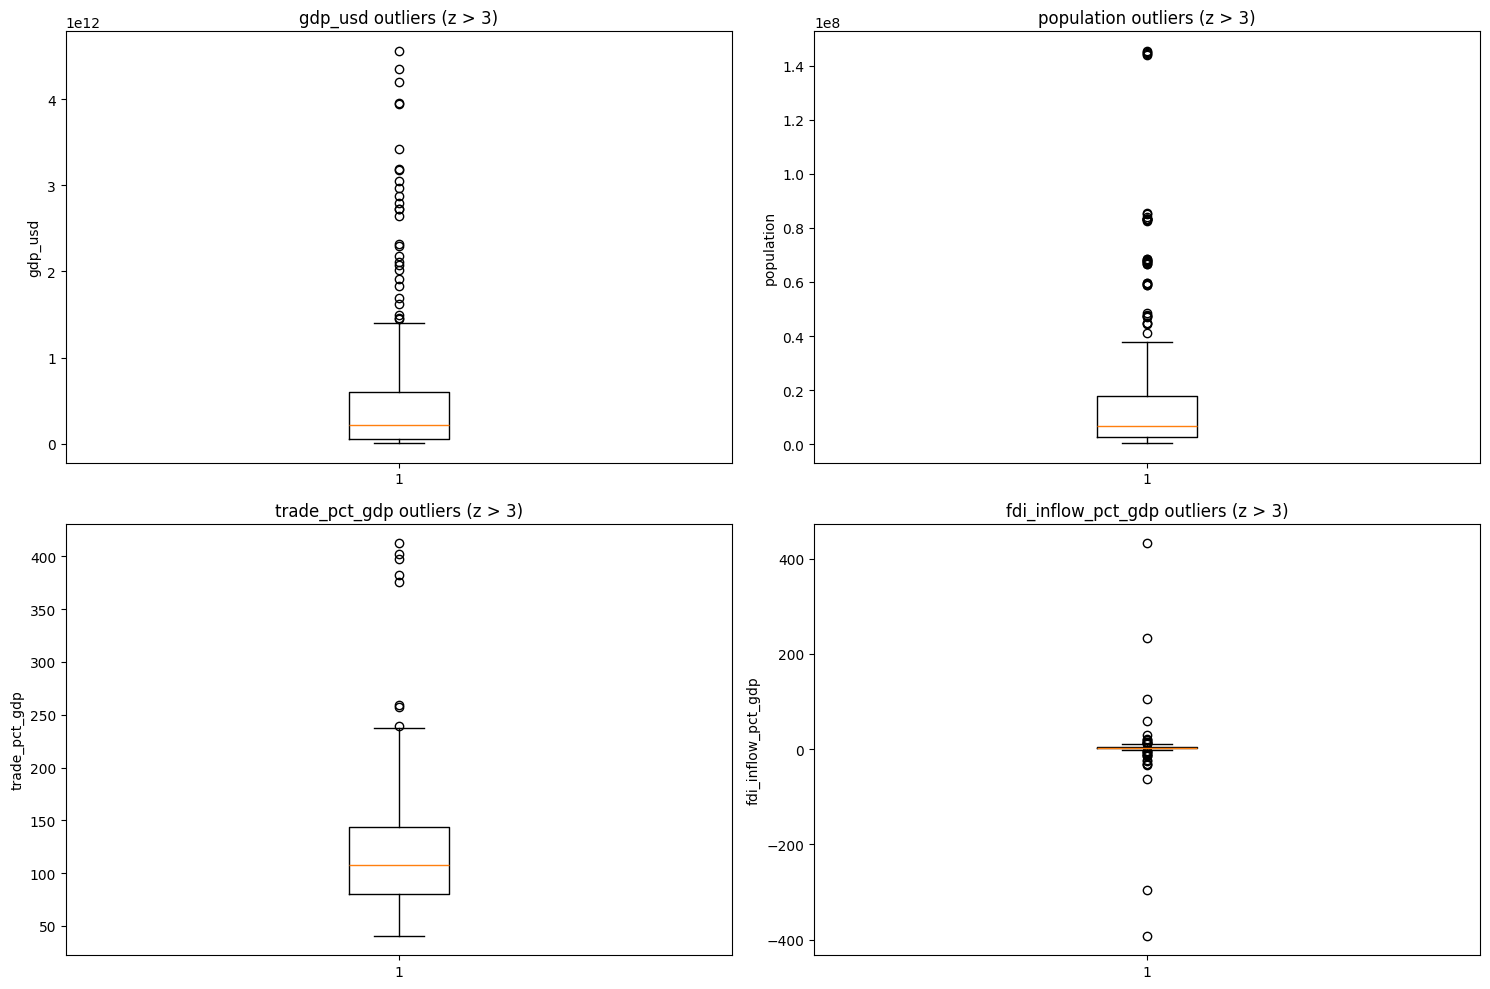

In [27]:
nodes = pd.read_csv('data/nodes.csv')
countries = pd.read_csv('data/countries.csv')

# Merge for visualization
nodes_with_meta = nodes.merge(
    countries[['iso3', 'country_name']], on='iso3'
)

indicator_cols = ['gdp_usd', 'population', 'trade_pct_gdp', 'fdi_inflow_pct_gdp']
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for i, col in enumerate(indicator_cols):
    # Z-score outliers
    z_scores = np.abs((nodes[col] - nodes[col].mean()) / nodes[col].std())
    outliers = nodes[z_scores > 3][['iso3', 'year', col]]
    
    axes[i].boxplot(nodes[col].dropna())
    axes[i].set_title(f'{col} outliers (z > 3)')
    axes[i].set_ylabel(col)
    
    print(f"\n{col} outliers (z-score > 3):")
    print(outliers.to_string(index=False))

plt.tight_layout()
plt.show()

>Outlier detection output reflection
>- `gdp_usd` outliers show that Germany and UK have z-score over 3.
>    - This indicates that the economy size of Germany and UK have were far greater than the majority countries in Europe.
>    - This is expected. Germany and UK are the largest European economies. The outcome matches reality. This is considered not an error or outlier.
>- `population` outliers show that Russia consistently has z-score over 3.
>    - This indicates that the population of Russia was far greater than the majority countries in Europe.
>    - This matches reality and is expected as Russia has been the largest population in Europe.
>- `trade_pct_gdp` outliers show that Luxembourg consistently has z-score over 3.
>    - This indicates that the trading size of Luxembourg took way more weight over its GDP compared to the majority countries in Europe.
>    - This matches reality and is expected as Luxembourg has been a financial center with massive trade flows relative to its tiny GDP. High % is normal for such hubs.
>- `fdi_inflow_pct_gdp` outliers show that Cyprus and Luxembourg have z-score over 3. 
>    - This indicates that the foreign direct investment net inflows of Cyprus and Luxembourg took way more weight over their GDP compared to the majority European countries.
>    - Cyprus is known as the tax haven that may result in volatile FDI flows.
>    - Luxembourg is known as the financial hub with extreme FDI swings due to corporate relocations.
>    - It is normal to see some negative numbers here for FDI outflows exceed inflows.
>    - For the dataset of this project, we are not 100% sure about the validity of the data and we decided to keep them, but flag with a fdi_outlier column for graph analysis
>
> Overall, we did not find any obvious data errors as all outliers are legitimate economic phenomena. We don't need to drop or adjust anything.

## Step 9: Build edges table

In [29]:
# Load country and node tables
countries = pd.read_csv('data/countries.csv')
nodes = pd.read_csv('data/nodes.csv')

# Use only countries we kept
country_codes = countries['comtrade_num'].dropna().astype(int).astype(str).tolist()

# Build country lookup for ISO3
lookup = countries.set_index('comtrade_num')['iso3'].to_dict()

# Fetch trade edges: reporter -> partner
# Try one reporter first to confirm the API works
reporter = country_codes[0]

df = comtradeapicall.previewFinalData(
    typeCode='C',
    freqCode='A',
    clCode='HS',
    period='2023',
    reporterCode=reporter,
    cmdCode='TOTAL',
    flowCode='X',
    partnerCode=','.join(country_codes),
    partner2Code=None,
    customsCode=None,
    motCode=None,
    maxRecords=500,
    format_output='JSON',
    aggregateBy=None,
    breakdownMode='classic',
    countOnly=None,
    includeDesc=True
)

print(df.head().to_string(index=False))
print(f"\nRows returned: {len(df)}")

Empty DataFrame
Columns: []
Index: []

Rows returned: 0


In [32]:
KEY = "8e386e6218fa4dc58b4a5b1fc63f0d86"  # From My Account → API Management

countries = pd.read_csv('data/countries.csv')
comtrade_codes = countries['comtrade_num'].dropna().astype(str).tolist()

# Test Germany (276) → all Europe, 2019 exports
df = comtradeapicall.getFinalData(
    KEY,  # subscription_key
    'C',  # typeCode
    'A',  # freqCode
    'HS', # clCode
    '2019', # period
    '276', # reporterCode (Germany)
    'TOTAL', # cmdCode
    'X',   # flowCode
    ','.join(['250', '826']), # partnerCode (France + UK)
    None,  # partner2Code
    None,  # customsCode
    None,  # motCode
    250000 # maxRecords
)
print(df.head(10).to_string(index=False))
print(f"Rows returned: {len(df)}")

typeCode freqCode  refPeriodId  refYear  refMonth period  reporterCode reporterISO reporterDesc flowCode flowDesc  partnerCode partnerISO partnerDesc  partner2Code partner2ISO partner2Desc classificationCode classificationSearchCode  isOriginalClassification cmdCode cmdDesc aggrLevel isLeaf customsCode customsDesc mosCode  motCode motDesc  qtyUnitCode qtyUnitAbbr  qty  isQtyEstimated  altQtyUnitCode altQtyUnitAbbr  altQty  isAltQtyEstimated  netWgt  isNetWgtEstimated  grossWgt  isGrossWgtEstimated cifvalue     fobvalue  primaryValue  legacyEstimationFlag  isReported  isAggregate
       C        A     20190101     2019        52   2019           276        None         None        X     None          826       None        None             0        None         None                 H5                       HS                      True   TOTAL    None      None   None         C00        None       0        0    None           -1        None  0.0           False              -1           N

In [35]:
KEY = "8e386e6218fa4dc58b4a5b1fc63f0d86"  # From portal
countries = pd.read_csv('data/countries.csv')
comtrade_codes = countries['comtrade_num'].dropna().astype(str).tolist()
years = ['2018','2019','2020','2021','2022','2023']

# Your team's subset of reporters (e.g. Team 1: first 17)
your_reporters = comtrade_codes[:17]  # CHANGE THIS FOR YOUR TEAM

all_edges = []
os.makedirs('data/cache', exist_ok=True)

for year in years:
    for reporter in your_reporters:
        print(f"{year} {reporter}...", end='')
        try:
            df = comtradeapicall.getFinalData(
                KEY, 'C', 'A', 'HS', year, reporter, 'TOTAL', 'X',  # Exports
                ','.join(comtrade_codes), None, None, None, 250000
            )
            if df is not None and len(df) > 0:
                all_edges.append(df)
                print(f" ✓ {len(df)} rows")
            else:
                print(" ✗ empty")
        except Exception as e:
            print(f" ✗ {e}")
        
        time.sleep(1.5)  # Rate limit

edges_raw = pd.concat(all_edges, ignore_index=True)
edges_raw.to_csv('data/edges_raw.csv', index=False)
print(f"\nYOUR TEAM: {len(edges_raw)} rows saved!")

2018 578.0...{"elapsedTime":"0 secs","count":-1,"data":[],"error":"Invalid parameter value","errorObject":[{"memberNames":["reporterCode"],"errorMessage":"The field reporterCode is invalid"},{"memberNames":["partnerCode"],"errorMessage":"The field partnerCode is invalid"}]}
 ✗ empty
2018 191.0...{"elapsedTime":"0 secs","count":-1,"data":[],"error":"Invalid parameter value","errorObject":[{"memberNames":["reporterCode"],"errorMessage":"The field reporterCode is invalid"},{"memberNames":["partnerCode"],"errorMessage":"The field partnerCode is invalid"}]}
 ✗ empty
2018 380.0...{"elapsedTime":"0 secs","count":-1,"data":[],"error":"Invalid parameter value","errorObject":[{"memberNames":["reporterCode"],"errorMessage":"The field reporterCode is invalid"},{"memberNames":["partnerCode"],"errorMessage":"The field partnerCode is invalid"}]}
 ✗ empty
2018 807.0...{"elapsedTime":"0 secs","count":-1,"data":[],"error":"Invalid parameter value","errorObject":[{"memberNames":["reporterCode"],"errorMes

ValueError: No objects to concatenate

In [ ]:
# Get valid reporters for your parameters
url = "https://comtradeapi.un.org/public/v1/getMetadata/C/A/HS?period=2019"
resp = requests.get(url)
data = resp.json()

reporters = pd.DataFrame(data.get('data', []))
print("Valid reporters for 2019:")
print(reporters[['id', 'text']].head(10))
print("\nYour comtrade_codes sample:")
countries = pd.read_csv('data/countries.csv')
print(countries['comtrade_num'].head(10).tolist())

Valid reporters for 2019:


KeyError: "None of [Index(['id', 'text'], dtype='object')] are in the [columns]"

In [37]:
countries = pd.read_csv('data/countries.csv')
print("Before:")
print(countries['comtrade_num'].head(10))

# Fix: convert to integer strings
countries['comtrade_num'] = countries['comtrade_num'].astype(int).astype(str)
countries.to_csv('data/countries.csv', index=False)

print("\nAfter:")
print(countries['comtrade_num'].head(10))

Before:
0    578.0
1    191.0
2    380.0
3    807.0
4    688.0
5    276.0
6    372.0
7    826.0
8    498.0
9    300.0
Name: comtrade_num, dtype: float64

After:
0    578
1    191
2    380
3    807
4    688
5    276
6    372
7    826
8    498
9    300
Name: comtrade_num, dtype: object


## Step 10: Filter Valid Reporters

In [40]:
KEY = "8e386e6218fa4dc58b4a5b1fc63f0d86"

df = comtradeapicall.getFinalData(
    KEY, 'C', 'A', 'HS', '2019', '276', 'TOTAL', 'X', '0',
    None, None, None, 250000
)
print(f"Success: {len(df) if hasattr(df, 'empty') else 'Not a DataFrame'} rows")
if hasattr(df, 'shape'):
    print(df.head(3))
    print(df.shape)

Success: 44 rows
  typeCode freqCode  refPeriodId  refYear  refMonth period  reporterCode  \
0        C        A     20190101     2019        52   2019           276   
1        C        A     20190101     2019        52   2019           276   
2        C        A     20190101     2019        52   2019           276   

  reporterISO reporterDesc flowCode  ... netWgt  isNetWgtEstimated grossWgt  \
0        None         None        X  ...    0.0              False      0.0   
1        None         None        X  ...    0.0               True      0.0   
2        None         None        X  ...    0.0               True      0.0   

  isGrossWgtEstimated  cifvalue      fobvalue  primaryValue  \
0               False      None  5.137359e+10  5.137359e+10   
1               False      None  7.106249e+09  7.106249e+09   
2               False      None  5.991005e+10  5.991005e+10   

  legacyEstimationFlag isReported  isAggregate  
0                    0      False         True  
1         

In [41]:
valid_reporters = []
for code in countries['comtrade_num'].head(20).tolist():
    try:
        df_test = comtradeapicall.getFinalData(
            KEY, 'C', 'A', 'HS', '2019', code, 'TOTAL', 'X', 
            '0', None, None, None, 250000
        )
        rows = len(df_test) if hasattr(df_test, 'shape') else 0
        if rows > 0:
            valid_reporters.append(code)
            print(f"✓ {code}: {rows} rows")
        else:
            print(f"✗ {code}: empty")
    except Exception as e:
        print(f"✗ {code}: error")
    time.sleep(0.5)  # Rate limit

print(f"\nValid: {valid_reporters}")

✗ 578: empty
✓ 191: 1 rows
✓ 380: 1 rows
✓ 807: 7 rows
✓ 688: 23 rows
✓ 276: 44 rows
✓ 372: 1 rows
✓ 826: 18 rows
✓ 498: 485 rows
✓ 300: 10 rows
✓ 792: 2140 rows
✓ 642: 10 rows
✓ 233: 208 rows
✗ 756: empty
✓ 428: 20 rows
✓ 752: 10 rows
✗ 234: empty
✓ 703: 40 rows
✓ 705: 36 rows
✗ 292: empty

Valid: ['191', '380', '807', '688', '276', '372', '826', '498', '300', '792', '642', '233', '428', '752', '703', '705']


> We see 16 valid reporters found here. It is normal as most countries don't report HS annual data, so 1 row = valid "World total".

In [42]:
countries_valid = countries[countries['comtrade_num'].isin(valid_reporters)]
countries_valid.to_csv('data/countries_valid.csv', index=False)
print(f"Saved {len(countries_valid)} valid reporters to countries_valid.csv")
print(countries_valid[['comtrade_num', 'name']].head(10))

Saved 16 valid reporters to countries_valid.csv


KeyError: "['name'] not in index"

In [44]:
print("Valid Reporters:")
print(countries_valid[['comtrade_num', 'country_name']].head(16))
countries_valid.to_csv('data/countries_valid.csv', index=False)  # Already done!

Valid Reporters:
   comtrade_num     country_name
1           191          Croatia
2           380            Italy
3           807  North Macedonia
4           688           Serbia
5           276          Germany
6           372          Ireland
7           826   United Kingdom
8           498          Moldova
9           300           Greece
10          792          Turkiye
11          642          Romania
12          233          Estonia
14          428           Latvia
15          752           Sweden
17          703  Slovak Republic
18          705         Slovenia


In [ ]:
# try top partners and some commodity

all_edges = []
top_partners = ['0', '276', '842', '124', '392', '156']  # World + top partners

for _, row in countries_valid.iterrows():
    reporter = row['comtrade_num']
    for year in range(2018, 2024):
        for partner in top_partners:
            try:
                df = comtradeapicall.getFinalData(
                    KEY, 'C', 'A', 'HS', str(year), reporter, partner, 'X', 
                    '250,826', None, None, None, 250000
                )
                if hasattr(df, 'shape') and len(df) > 0:
                    df['reporter'] = reporter
                    df['partner'] = partner
                    df['year'] = year
                    all_edges.append(df)
                    print(f"✓ {year} {reporter}→{partner}: {len(df)}")
                else:
                    print(f"✗ {year} {reporter}→{partner}: empty")
            except Exception as e:
                print(f"✗ {year} {reporter}→{partner}: {e}")
            time.sleep(1.5)  # Rate limit

edges_raw = pd.concat(all_edges, ignore_index=True)
edges_raw.to_csv('data/edges_raw.csv', index=False)
# try 3 countries and 2 years in case of wasting quota and time
print(f"SUCCESS: {len(edges_raw)} total edges saved!")

✗ 2018 191→0: empty
✗ 2018 191→276: empty
✗ 2018 191→842: empty
✗ 2018 191→124: empty
✗ 2018 191→392: empty
✗ 2018 191→156: empty
✗ 2019 191→0: empty
✗ 2019 191→276: empty
✗ 2019 191→842: empty
✗ 2019 191→124: empty
✗ 2019 191→392: empty
✗ 2019 191→156: empty
✗ 2020 191→0: empty
✗ 2020 191→276: empty
✗ 2020 191→842: empty
✗ 2020 191→124: empty
✗ 2020 191→392: empty
✗ 2020 191→156: empty
✗ 2021 191→0: empty
✗ 2021 191→276: empty
✗ 2021 191→842: empty
✗ 2021 191→124: empty
✗ 2021 191→392: empty
✗ 2021 191→156: empty
✗ 2022 191→0: empty
✗ 2022 191→276: empty
✗ 2022 191→842: empty
✗ 2022 191→124: empty
✗ 2022 191→392: empty
✗ 2022 191→156: empty
✗ 2023 191→0: empty
✗ 2023 191→276: empty
✗ 2023 191→842: empty
✗ 2023 191→124: empty
✗ 2023 191→392: empty
✗ 2023 191→156: empty
✗ 2018 380→0: empty
✗ 2018 380→276: empty
✗ 2018 380→842: empty
✗ 2018 380→124: empty
✗ 2018 380→392: empty
✗ 2018 380→156: empty
✗ 2019 380→0: empty
✗ 2019 380→276: empty
✗ 2019 380→842: empty
✗ 2019 380→124: empty
✗ 20

KeyboardInterrupt: 

In [18]:
# make a trial in case of wasting quota and time

KEY1 = "ca843ca986cb49a5b15a28474a60df33" # use Yirang's key for world totals
BASE = "https://comtradeapi.un.org/data/v1/get/C/A/HS"

params = {
    "reporterCode": "380",
    "period": "2019",
    "partnerCode": "276",
    "cmdCode": "AG2",
    "flowCode": "X",
    "subscription-key": KEY1
}
resp = requests.get(BASE, params=params)
data = resp.json()

print("Count:", data.get('count'))
if data.get('data'):
    row = data['data'][0]
    print("cifvalue:", row.get('cifvalue'))
    print("primaryValue:", row.get('primaryValue'))

Count: 97
cifvalue: None
primaryValue: 1233326706.105


In [20]:
# Full trade trial

params = {
    "reporterCode": "380",
    "period": "2019",
    "partnerCode": "276",  # Germany
    "cmdCode": "TOTAL",    # ALL products
    "flowCode": "X",
    "subscription-key": KEY1
}
resp = requests.get(BASE, params=params)
data = resp.json()
print("TOTAL Count:", data.get('count'))
if data.get('data'):
    value = sum(r.get('primaryValue', 0) for r in data['data'])
    print("Italy→Germany TOTAL 2019: ${:,.0f}".format(value))

TOTAL Count: 1
Italy→Germany TOTAL 2019: $65,509,540,986


> We chose to only use AG2 = "2-digit HS aggregate" (~99 product groups). Jason's notebook used it because detailed HS codes = quota explosion.

In [21]:

KEY1 = "your_new_primary_key"
BASE = "https://comtradeapi.un.org/data/v1/get/C/A/HS"

# "4 country codes" = top_partners (Germany, USA, China, Canada) — each European reporter → these 4 = dense network.
top_partners = ['276', '842', '156', '124']  # Germany, USA, China, Canada
all_countries = pd.read_csv('data/countries.csv')['comtrade_num'].astype(str).tolist()
edges = []

def get_trade(reporter, partner, year):
    params = {
        "reporterCode": reporter,
        "period": str(year),
        "partnerCode": partner,
        "cmdCode": "TOTAL",
        "flowCode": "X",
        "subscription-key": KEY1
    }
    resp = requests.get(BASE, params=params)
    data = resp.json()
    if resp.status_code == 200 and data.get('data'):
        return sum(r.get('primaryValue', 0) for r in data['data'])
    return 0

# Batch 1: 2019 only, first 20 countries
batch_countries = all_countries[:20]
for reporter in batch_countries:
    for partner in top_partners:
        value = get_trade(reporter, partner, 2019)
        if value > 0:
            edges.append({'year': 2019, 'reporter': reporter, 'partner': partner, 'exports': value})
            print(f"✓ {reporter}→{partner} 2019: ${value:,.0f}")
        time.sleep(1)

pd.DataFrame(edges).to_csv('data/europe_exports_2019.csv', index=False)
print(f"✅ Batch 1: {len(edges)} edges")

✅ Batch 1: 0 edges


In [ ]:
params = {
    "reporterCode": "380",
    "period": "2019",
    "partnerCode": "276",  # Germany
    "cmdCode": "TOTAL",    # ALL products
    "flowCode": "X",
    "subscription-key": KEY1
}
resp = requests.get(BASE, params=params)
data = resp.json()
print("TOTAL Count:", data.get('count'))
if data.get('data'):
    value = sum(r.get('primaryValue', 0) for r in data['data'])
    print("Italy→Germany TOTAL 2019: ${:,.0f}".format(value))